# AI Zero to Hero: End of Course Practical Assessment
## Practical Data Analysis: EDA, Predictive Modelling, and Hierarchical Clustering

Welcome to the end-of-course practical assessment! In this notebook, you will apply the concepts learned across the course using Python in Google Colab.

### Objectives:
1. **Mount Google Drive** and prepare your environment.
2. Perform **Exploratory Data Analysis (EDA)** on an environmental and geographic dataset.
3. Build and evaluate **Predictive Regression and Classification Models**.
4. Apply **Hierarchical Agglomerative Clustering** and interpret dendrograms.

---

## Task 0: Setup and Mount Google Drive
Run the cell below to load the required Python libraries and mount your Google Drive.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Set up assessment folder
assessment_folder = 'outputs'
os.makedirs(assessment_folder, exist_ok=True)
print("Setup complete. Saving folder initialized at:", assessment_folder)

Setup complete. Saving folder initialized at: outputs


---
# Section 1: Exploratory Data Analysis (EDA)

We will be working with the **California Environmental & Geographic Dataset**, which measures spatial and environmental block metrics such as spatial coordinates (`Latitude`, `Longitude`), population density, room counts, and median income.
Below, we load the dataset into a Pandas DataFrame.

In [2]:
# Load dataset (sampling 500 rows for fast hierarchical clustering demonstration)
env_raw = fetch_california_housing(as_frame=True)
df = env_raw.frame.sample(n=500, random_state=42).reset_index(drop=True)

# Display first few rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.47700
1,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.45800
2,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,5.00001
3,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.18600
4,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.78000


### Code Example 1.1: Calculating Summary Statistics
Here is how we calculate the mean, standard deviation, and summary statistics for the `Latitude` feature:

In [3]:
mean_lat = df['Latitude'].mean()
std_lat = df['Latitude'].std()
print(f"Latitude - Mean: {mean_lat:.2f}, SD: {std_lat:.2f}")
df[['Latitude']].describe()

Latitude - Mean: 35.49, SD: 2.12


,Latitude
count,500.00000
mean,35.49154
std,2.12106
min,32.59000
25%,33.94000
50%,34.19000
75%,37.58000
max,41.40000


### ✏️ Exercise 1.1
Modify the code below to calculate the mean, standard deviation, and summary statistics for the **`Longitude`** variable instead of `Latitude`.

In [4]:
# --- YOUR CODE HERE ---
# Change 'Latitude' to 'Longitude'
mean_lon = df['Latitude'].mean()
std_lon = df['Latitude'].std()
print(f"Longitude - Mean: {mean_lon:.2f}, SD: {std_lon:.2f}")
df[['Latitude']].describe()

Longitude - Mean: 35.49, SD: 2.12


,Latitude
count,500.00000
mean,35.49154
std,2.12106
min,32.59000
25%,33.94000
50%,34.19000
75%,37.58000
max,41.40000


### Code Example 1.2: Scatter Plots and Saving Figures
We can plot geographic spatial coordinates (`Longitude` vs `Latitude`) to visualize geographic distribution and save the figure to Google Drive.

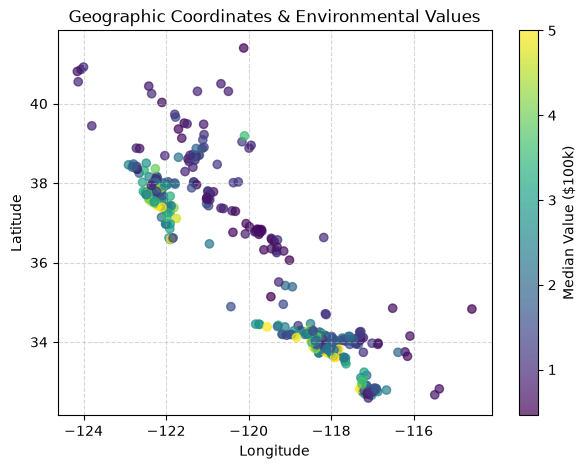

Figure saved to: outputs\geographic_distribution.png


In [5]:
plt.figure(figsize=(7, 5))
plt.scatter(df['Longitude'], df['Latitude'], c=df['MedHouseVal'], cmap='viridis', alpha=0.7)
plt.colorbar(label='Median Value ($100k)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Coordinates & Environmental Values')
plt.grid(True, linestyle='--', alpha=0.5)

# Save plot
fig_path = os.path.join(assessment_folder, 'geographic_distribution.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved to:', fig_path)

### ✏️ Exercise 1.2
Alter the code below to plot **`Population`** on the X-axis and **`MedHouseVal`** on the Y-axis. Change the point color to `'seagreen'` and save the figure as `'population_vs_value.png'`.

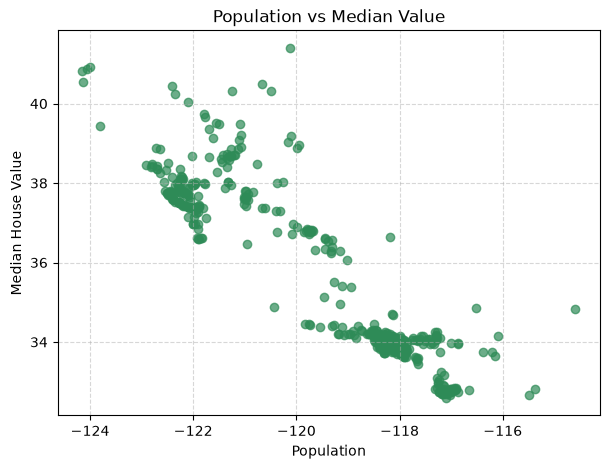

In [6]:
# --- YOUR CODE HERE ---
plt.figure(figsize=(7, 5))
plt.scatter(df['Longitude'], df['Latitude'], color='seagreen', alpha=0.7) # Modify X and Y
plt.xlabel('Population')
plt.ylabel('Median House Value')
plt.title('Population vs Median Value')
plt.grid(True, linestyle='--', alpha=0.5)

fig_path = os.path.join(assessment_folder, 'geographic_distribution.png') # Update filename
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

---
# Section 2: Predictive Modelling

## 2.1 Regression
Suppose we want to predict the continuous **`MedHouseVal`** target based on environmental and geographic indicators.

In [7]:
# Target continuous variable
y_reg = df['MedHouseVal']

# Feature: Median Income
X_reg1 = df[['MedInc']]

# Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X_reg1, y_reg, test_size=0.25, random_state=42)

# Fit Simple Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print(f"Simple Regression R2 Score: {r2_score(y_test, y_pred):.3f}")
print(f"Simple Regression RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")

Simple Regression R2 Score: 0.562
Simple Regression RMSE: 0.806


### ✏️ Exercise 2.1
Now perform a **Multiple Linear Regression** predicting `MedHouseVal` using **three features**: `['MedInc', 'Latitude', 'Longitude']`.
Calculate and report the $R^2$ and RMSE on the test set. Did adding spatial coordinates improve performance?

In [8]:
# --- YOUR CODE HERE ---
X_reg2 = df[['MedInc']] # Alter this list to include all 3 features

X_train, X_test, y_train, y_test = train_test_split(X_reg2, y_reg, test_size=0.25, random_state=42)

mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)
y_pred_multi = mlr_model.predict(X_test)

print(f"Multiple Regression R2 Score: {r2_score(y_test, y_pred_multi):.3f}")
print(f"Multiple Regression RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_multi)):.3f}")

Multiple Regression R2 Score: 0.562
Multiple Regression RMSE: 0.806


## 2.2 Classification
We can convert the target value into a binary category: **High Value Region** (1) vs **Low Value Region** (0) based on whether the score is above or below the median.

Classification Accuracy: 87.33%


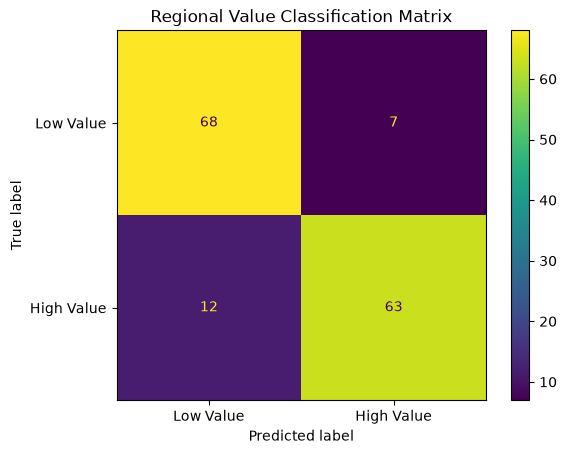

In [9]:
# Create binary classification target
median_val = df['MedHouseVal'].median()
df['high_value'] = (df['MedHouseVal'] > median_val).astype(int)

X_clf = df.drop(columns=['MedHouseVal', 'high_value'])
y_clf = df['high_value']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42)

# Standardize features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)

# Train Logistic Regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train_c)

y_clf_pred = clf.predict(X_test_scaled)
acc = accuracy_score(y_test_c, y_clf_pred)
print(f"Classification Accuracy: {acc * 100:.2f}%")

# Display Confusion Matrix
cm = confusion_matrix(y_test_c, y_clf_pred)
ConfusionMatrixDisplay(cm, display_labels=['Low Value', 'High Value']).plot()
plt.title('Regional Value Classification Matrix')
plt.show()

### 💬 Reflection Question 2.1
Examine the confusion matrix above. How accurately did the logistic regression model classify high vs low value regions using geographic and demographic features?

---
# Section 3: Hierarchical Agglomerative Clustering

In unsupervised learning, we group observations without using predefined ground-truth labels. Hierarchical Agglomerative Clustering builds a nested tree structure (dendrogram) based on pairwise distances.

### Code Example 3.1: Standardisation and Dendrogram Plotting
Distance metrics are sensitive to variable scales. Therefore, we standardize features before clustering.

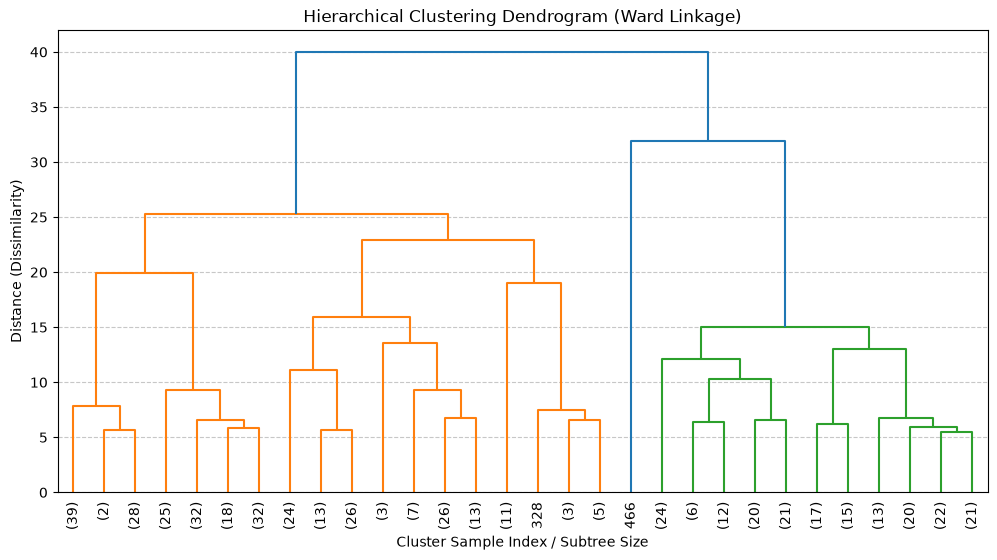

In [10]:
# Select numerical features (excluding targets)
features = df.drop(columns=['MedHouseVal', 'high_value'])

# Scale dataset
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Perform Hierarchical Clustering using Ward linkage
linked_ward = linkage(scaled_features, method='ward')

# Plot Dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked_ward, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10.)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Cluster Sample Index / Subtree Size')
plt.ylabel('Distance (Dissimilarity)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### ✏️ Exercise 3.1
Change the linkage method in the code below from `'ward'` to **`'complete'`**. Run the cell and observe how the structure of the dendrogram changes.

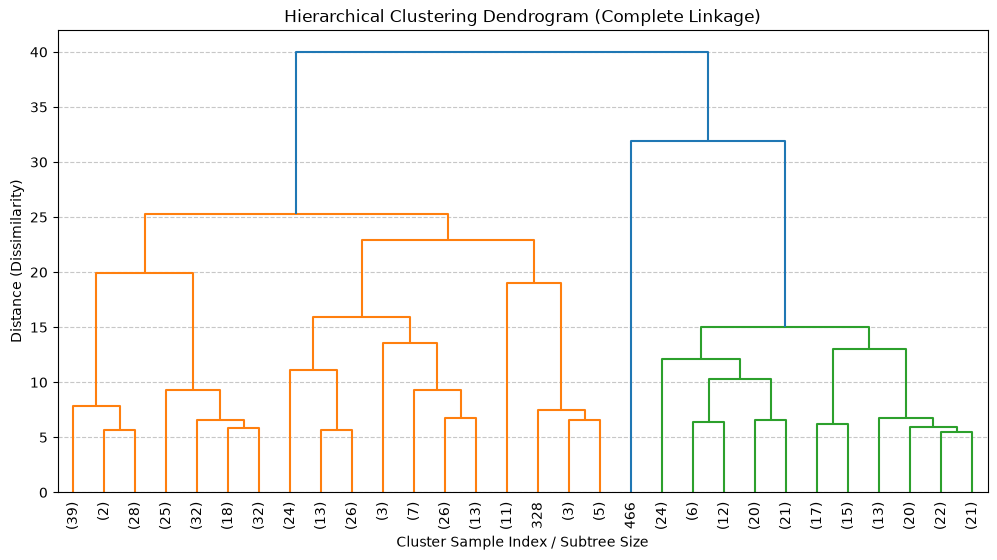

In [11]:
# --- YOUR CODE HERE ---
# Change method='ward' to method='complete'
linked_complete = linkage(scaled_features, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked_complete, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10.)
plt.title('Hierarchical Clustering Dendrogram (Complete Linkage)')
plt.xlabel('Cluster Sample Index / Subtree Size')
plt.ylabel('Distance (Dissimilarity)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Code Example 3.2: Cutting the Dendrogram into Clusters
We can cut the dendrogram to form $k=2$ distinct geographical/environmental clusters and compare them against actual high vs low value regions.

In [12]:
# Extract 2 clusters from the Ward linkage tree
cluster_labels = fcluster(linked_ward, t=2, criterion='maxclust')

# Assign cluster IDs to the dataframe
df['Cluster_ID'] = cluster_labels

# Map target integer labels to actual names
df['Region_Category'] = df['high_value'].map({0: 'Low Value Region', 1: 'High Value Region'})

# Compare cluster IDs with ground-truth region category
pd.crosstab(df['Region_Category'], df['Cluster_ID'], rownames=['Actual Category'], colnames=['Assigned Cluster'])

Assigned Cluster,1,2
Actual Category,,
High Value Region,165,85
Low Value Region,143,107


### 💬 Reflection Question 3.1
Based on the cross-tabulation table above, how well did unsupervised hierarchical clustering group the geographic regions? Why might environmental spatial features form natural clusters?

---
# Summary & Final Checklist

Congratulations on completing the assessment! Check that you have:
- [ ] Completed all code modifications in **Exercises 1.1, 1.2, 2.1, and 3.1**.
- [ ] Saved output plots and verified that they appear in your Google Drive assessment folder.
- [ ] Answered all text reflection questions in markdown.